# <u>Métodos No Supervisados - EXTRA

# Comparación de Cluster solo Usando la métrica de Silueta

## Librerias

In [11]:
#!pip install pyclustering

In [12]:
from pyclustering.cluster.clarans import clarans;
from pyclustering.utils import timedcall;
from pyclustering.cluster.kmedoids import kmedoids; #usa el mediode para realizar el clustering
import pandas as pd
import numpy as np

# visualization
import seaborn as sns
import matplotlib.pyplot as plt


In [13]:
basket = pd.read_csv(r"base de datos\basketball.csv")
basket.head(8)

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto
0,0.0888,201,36.02,28,0.5885
1,0.1399,198,39.32,30,0.8291
2,0.0747,198,38.80,26,0.4974
3,0.0983,191,40.71,30,0.5772
4,0.1276,196,38.40,28,0.5703
5,0.1671,201,34.10,31,0.5835
6,0.1906,193,36.20,30,0.5276
7,0.1061,191,36.75,27,0.5523


### Analizamos la data

In [14]:
basket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   asisten_porcen_minuto  96 non-null     float64
 1   talla                  96 non-null     int64  
 2   tiempo_juego           96 non-null     float64
 3   edad                   96 non-null     int64  
 4   puntos_porcen_minuto   96 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.9 KB


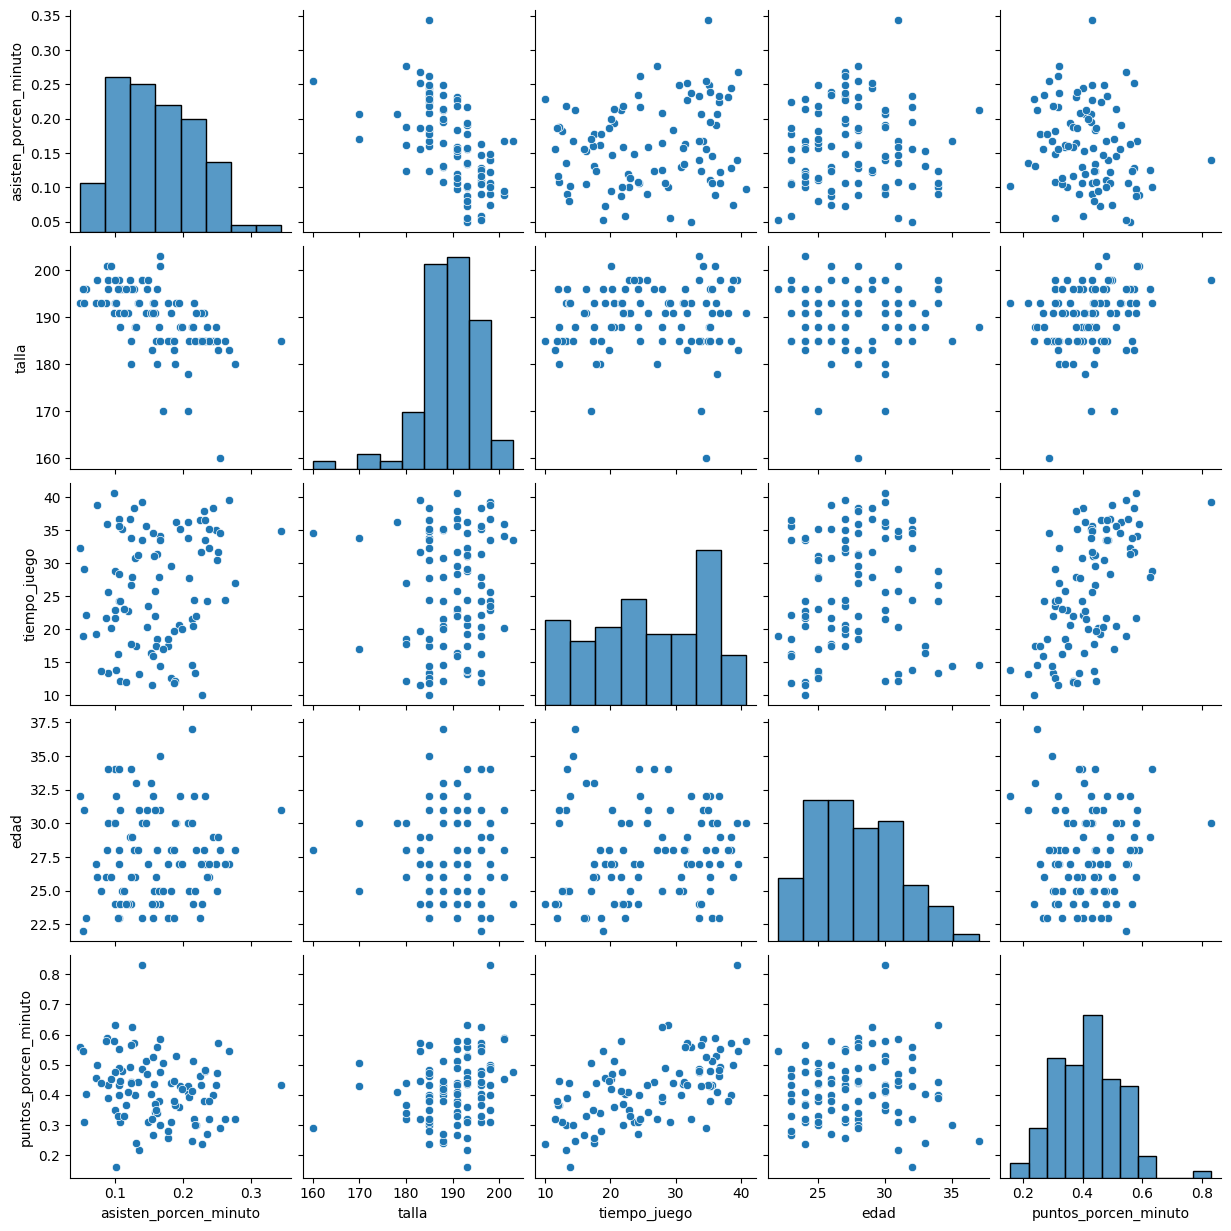

In [15]:
sns.pairplot(basket)

In [40]:
basket.corr()

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto
asisten_porcen_minuto,1.000000,-0.575778,0.177379,0.023146,-0.212271
talla,-0.575778,1.000000,0.069670,0.035416,0.249970
tiempo_juego,0.177379,0.069670,1.000000,0.077038,0.563599
edad,0.023146,0.035416,0.077038,1.000000,0.025722
puntos_porcen_minuto,-0.212271,0.249970,0.563599,0.025722,1.000000


## Clustering Jerarquico

### Normalizamos los datos

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1)) #normalizar las variables
scaler = scaler.fit(basket)
normalized = scaler.transform(basket)
normalized1 = pd.DataFrame(normalized,columns=list(basket.columns))
zscore_df = normalized1
zscore_df.head(10)

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto
0,0.133877,0.953488,0.846882,0.400000,0.640788
1,0.307509,0.883721,0.954620,0.533333,1.000000
2,0.085967,0.883721,0.937643,0.266667,0.504778
3,0.166157,0.720930,1.000000,0.533333,0.623918
4,0.265715,0.837209,0.924584,0.400000,0.613616
5,0.399932,0.953488,0.784198,0.600000,0.633323
6,0.479783,0.767442,0.852759,0.533333,0.549866
7,0.192661,0.720930,0.870715,0.333333,0.586742
8,0.663269,0.581395,0.925563,0.466667,0.360406
9,0.399592,1.000000,0.765916,0.133333,0.474321


### Estandarizamos los datos

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler = scaler.fit(basket)
standarizar = scaler.transform(basket)
standarizar1 = pd.DataFrame(standarizar,columns=list(basket.columns))
zscore_df1 = standarizar1
zscore_df1.head(10)

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto
0,-1.218687,1.606715,1.174850,0.078724,1.553464
1,-0.359587,1.173443,1.559641,0.683326,3.775175
2,-1.455738,1.173443,1.499007,-0.525878,0.712243
3,-1.058972,0.162477,1.721720,0.683326,1.449120
4,-0.566376,0.884596,1.452366,0.078724,1.385405
5,0.097703,1.606715,0.950972,0.985628,1.507294
6,0.492788,0.451324,1.195839,0.683326,0.991111
7,-0.927837,0.162477,1.259971,-0.223577,1.219192
8,1.400643,-0.704066,1.455864,0.381025,-0.180689
9,0.096022,1.895562,0.885674,-1.130480,0.523868


Al momento de normalizar los datos solo usar un método

## Dendograma

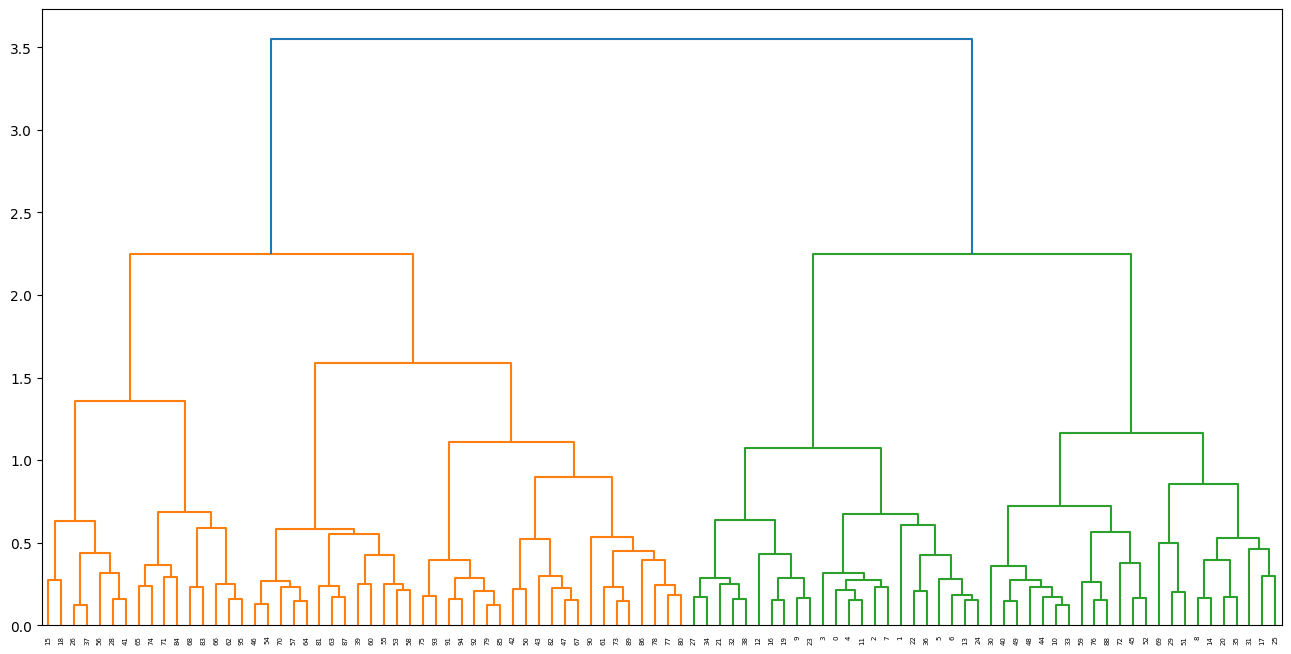

In [43]:
from scipy.cluster.hierarchy import dendrogram, linkage  
from matplotlib import pyplot as plt

seed = 16
np.random.seed(seed)

linked = linkage(zscore_df,method = 'ward')

labelList = range(1, 11)

plt.figure(figsize=(16, 8))  
dendrogram(linked)
plt.show()  

## Construimos el Modelo Jerarquico con 4 cluster

In [44]:
from sklearn.cluster import AgglomerativeClustering

seed = 16
np.random.seed(seed)

cluster_Ag = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')  
cluster_Ag.fit_predict(zscore_df)   ## Recordar que aca se reemplaza su dataframe

array([2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 3, 1, 2, 3, 1, 2, 3, 2,
       2, 2, 2, 3, 1, 2, 1, 3, 3, 3, 2, 3, 2, 3, 2, 1, 2, 0, 3, 1, 0, 0,
       3, 3, 0, 0, 3, 3, 0, 3, 3, 0, 0, 0, 1, 0, 0, 3, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 3, 0, 1, 3, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       3, 0, 0, 0, 0, 0, 0, 1], dtype=int64)

In [45]:
label_ag = pd.DataFrame(cluster_Ag.labels_,columns= ['Cluster'])
cluster_Jerarq = pd.concat([basket,label_ag['Cluster']], axis=1)
cluster_Jerarq

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto,Cluster
0,0.0888,201,36.02,28,0.5885,2
1,0.1399,198,39.32,30,0.8291,2
2,0.0747,198,38.80,26,0.4974,2
3,0.0983,191,40.71,30,0.5772,2
4,0.1276,196,38.40,28,0.5703,2
...,...,...,...,...,...,...
91,0.1554,183,11.58,24,0.3195,0
92,0.2282,185,10.08,24,0.2381,0
93,0.1778,185,18.56,23,0.2802,0
94,0.1863,185,11.81,23,0.3810,0


In [46]:
cluster_Ag.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 3, 1, 2, 3, 1, 2, 3, 2,
       2, 2, 2, 3, 1, 2, 1, 3, 3, 3, 2, 3, 2, 3, 2, 1, 2, 0, 3, 1, 0, 0,
       3, 3, 0, 0, 3, 3, 0, 3, 3, 0, 0, 0, 1, 0, 0, 3, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 3, 0, 1, 3, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       3, 0, 0, 0, 0, 0, 0, 1], dtype=int64)

In [22]:
cluster_Jerarq.columns

Index(['asisten_porcen_minuto', 'talla', 'tiempo_juego', 'edad',
       'puntos_porcen_minuto', 'Cluster'],
      dtype='object')

## Visualizacion en 2D

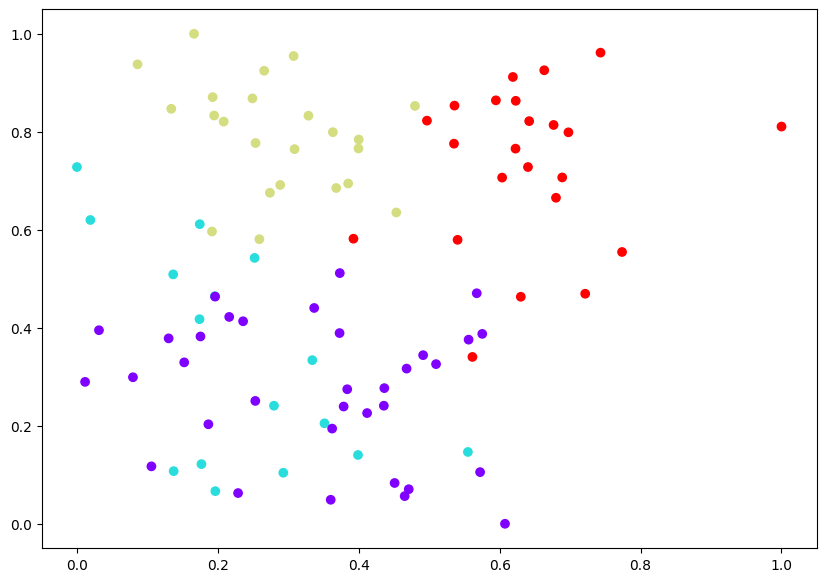

In [47]:
plt.figure(figsize=(10, 7))  
plt.scatter(zscore_df['asisten_porcen_minuto'], zscore_df['tiempo_juego'], c=cluster_Ag.labels_ , cmap='rainbow') 

## Visualizacion en 3D

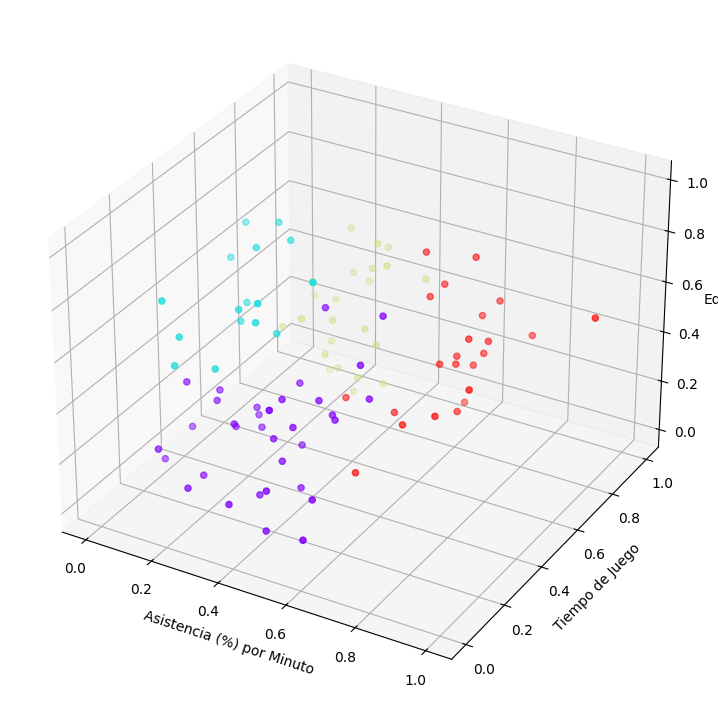

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configuración del tamaño de la figura
plt.rcParams['figure.figsize'] = (18, 9)

# Crear la figura y el subplot 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Asegúrate de que no haya valores NaN en los datos
ax.scatter(zscore_df['asisten_porcen_minuto'], 
           zscore_df['tiempo_juego'], 
           zscore_df['edad'], 
           c=cluster_Ag.labels_, cmap='rainbow')

# Etiquetas de los ejes
ax.set_xlabel('Asistencia (%) por Minuto')
ax.set_ylabel('Tiempo de Juego')
ax.set_zlabel('Edad')

# Mostrar el gráfico
plt.show()


In [49]:
from sklearn.metrics import silhouette_score
silhouette_score(basket.values, cluster_Ag.labels_, metric='euclidean')

0.19387787288772884

calculamos la métrica de silueta, se observa que esta relativamente bajo

## Usamos Kmedoides con P.A.M

Debemos de fijar la cantidad de cluster

In [53]:
seed = 16 # con esto definimos la semilla o con random_state
np.random.seed(seed)

kmedoids_instance = kmedoids(zscore_df.values, [3, 6, 4,10],random_state=16); ## para probar mas cluster solo agregar en
# la lista [3, 6, 4] aca seria para 3 cluster si quieres 4 agrega [3, 6, 4, 10] un valor cualesquiera por que son aleatorios

#calls the clarans method 'process' to implement the algortihm
(ticks, result) = timedcall(kmedoids_instance.process);
print("Execution time : ", ticks, "\n");

#returns the clusters 
clusters_Kmed = kmedoids_instance.get_clusters();

#returns the mediods 
medoids = kmedoids_instance.get_medoids();

print("Index of the points that are in a cluster : ",clusters_Kmed)
print("The index of medoids that algorithm found to be best :", medoids)

Execution time :  0.005546799977310002 

Index of the points that are in a cluster :  [[39, 43, 45, 46, 47, 53, 54, 55, 57, 58, 60, 63, 64, 67, 70, 72, 73, 75, 76, 77, 78, 79, 80, 81, 82, 85, 86, 87, 89, 90, 91, 92, 93, 94], [26, 37, 41, 42, 50, 61, 62, 65, 66, 68, 71, 74, 83, 84, 95], [0, 1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 15, 16, 18, 19, 22, 23, 24, 27, 28, 32, 36, 38, 56], [8, 10, 12, 14, 17, 20, 21, 25, 29, 30, 31, 33, 34, 35, 40, 44, 48, 49, 51, 52, 59, 69, 88]]
The index of medoids that algorithm found to be best : [80, 74, 11, 33]


Adecuamos los cluster con etiquetas

In [54]:
label = pd.DataFrame()
for i in range(4):  # Esto es para 3 cluster si quiero 4 cambio aca el valor anda mas  
    print(i)
    a = pd.DataFrame(clusters_Kmed[i],columns = ['Index']) 
    a['Cluster'] = i
    label = pd.concat([label,a])

0
1
2
3


In [55]:
label

,Index,Cluster
0,39,0
1,43,0
2,45,0
3,46,0
4,47,0
...,...,...
18,51,3
19,52,3
20,59,3
21,69,3


In [56]:
label_f = label.sort_values(by ='Index').reset_index(drop='true')
cluster_Med = pd.concat([basket,label_f['Cluster']], axis=1)
cluster_Med

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto,Cluster
0,0.0888,201,36.02,28,0.5885,2
1,0.1399,198,39.32,30,0.8291,2
2,0.0747,198,38.80,26,0.4974,2
3,0.0983,191,40.71,30,0.5772,2
4,0.1276,196,38.40,28,0.5703,2
...,...,...,...,...,...,...
91,0.1554,183,11.58,24,0.3195,0
92,0.2282,185,10.08,24,0.2381,0
93,0.1778,185,18.56,23,0.2802,0
94,0.1863,185,11.81,23,0.3810,0


In [30]:
cluster_Med.Cluster.value_counts()

Cluster
0    34
2    24
3    23
1    15
Name: count, dtype: int64

## Visualizacion en 2D

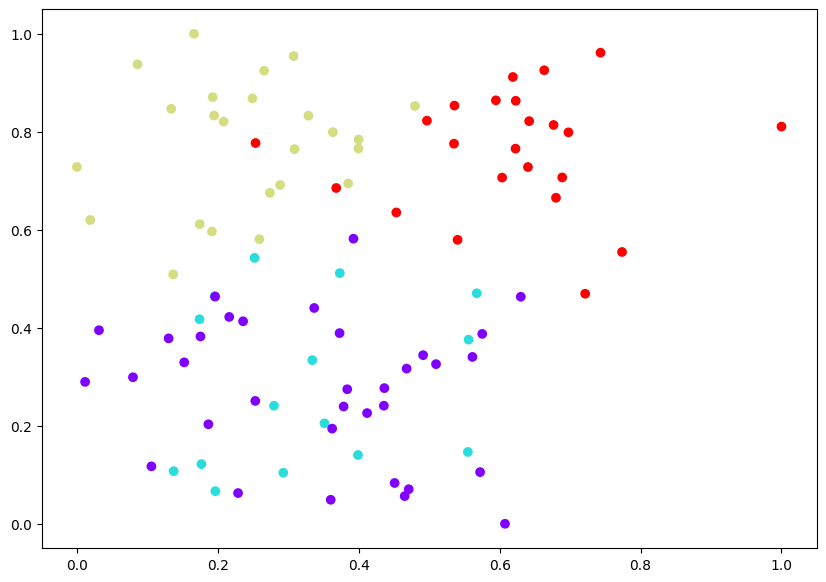

In [61]:
plt.figure(figsize=(10, 7))  
plt.scatter(zscore_df['asisten_porcen_minuto'], zscore_df['tiempo_juego'], c=cluster_Med.Cluster, cmap='rainbow') 

## Visualizacion en 3D

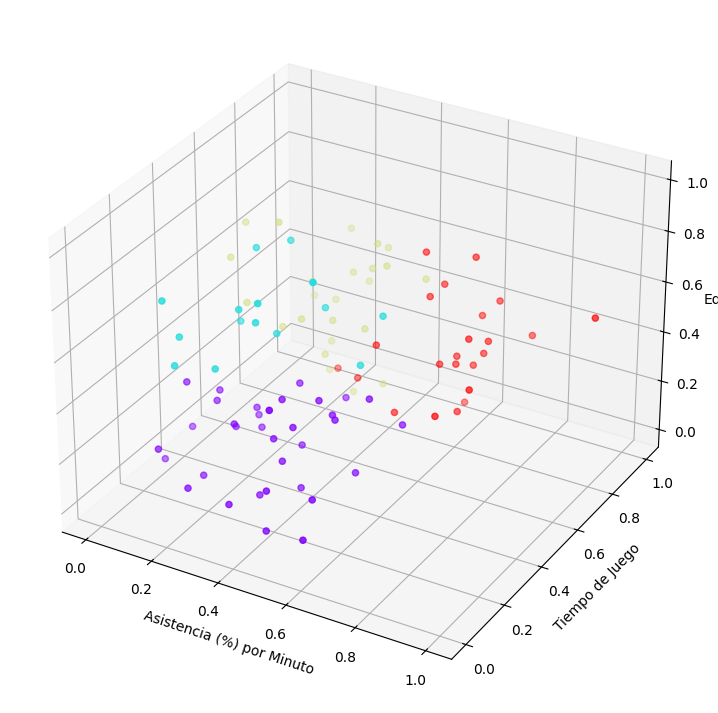

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (18, 9)
fig = plt.figure()
#ax = Axes3D(fig)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(zscore_df.asisten_porcen_minuto, zscore_df.tiempo_juego, zscore_df.edad, c=cluster_Med.Cluster,cmap='rainbow')

# Etiquetas de los ejes
ax.set_xlabel('Asistencia (%) por Minuto')
ax.set_ylabel('Tiempo de Juego')
ax.set_zlabel('Edad')

# Mostrar el gráfico
plt.show()

### Métrica de Silueta

In [62]:
from sklearn.metrics import silhouette_score
silhouette_score(basket.values, cluster_Med.Cluster, metric='euclidean')

0.22289836852175848

cuento mas grande la silueta mejor, indica que cada cluster los cluster estan bien definidos

## Usamos Kmeans

In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,random_state=16)
kmeans.fit(zscore_df.values)
centroids = kmeans.cluster_centers_
print("The index of kemans that algorithm found to be best :", kmeans.labels_)

The index of kemans that algorithm found to be best : [3 3 3 3 3 3 3 3 0 3 0 3 3 3 0 3 3 0 3 3 0 0 3 3 3 0 1 3 1 0 0 0 3 0 3 0 3
 1 3 2 0 1 1 2 0 2 2 2 0 0 1 0 0 2 2 2 1 2 2 0 2 1 1 2 2 1 1 2 1 0 2 1 2 2
 1 2 0 2 2 2 2 2 2 1 1 2 1 2 0 2 2 2 2 2 2 1]


Adecuamos los cluster con etiquetas

In [64]:
label_km = pd.DataFrame(kmeans.labels_,columns= ['Cluster'])
cluster_kmeans = pd.concat([basket,label_km['Cluster']], axis=1)
cluster_kmeans

,asisten_porcen_minuto,talla,tiempo_juego,edad,puntos_porcen_minuto,Cluster
0,0.0888,201,36.02,28,0.5885,3
1,0.1399,198,39.32,30,0.8291,3
2,0.0747,198,38.80,26,0.4974,3
3,0.0983,191,40.71,30,0.5772,3
4,0.1276,196,38.40,28,0.5703,3
...,...,...,...,...,...,...
91,0.1554,183,11.58,24,0.3195,2
92,0.2282,185,10.08,24,0.2381,2
93,0.1778,185,18.56,23,0.2802,2
94,0.1863,185,11.81,23,0.3810,2


In [65]:
cluster_kmeans.Cluster.value_counts()

Cluster
2    32
3    24
0    22
1    18
Name: count, dtype: int64

## Visualizacion en 2D

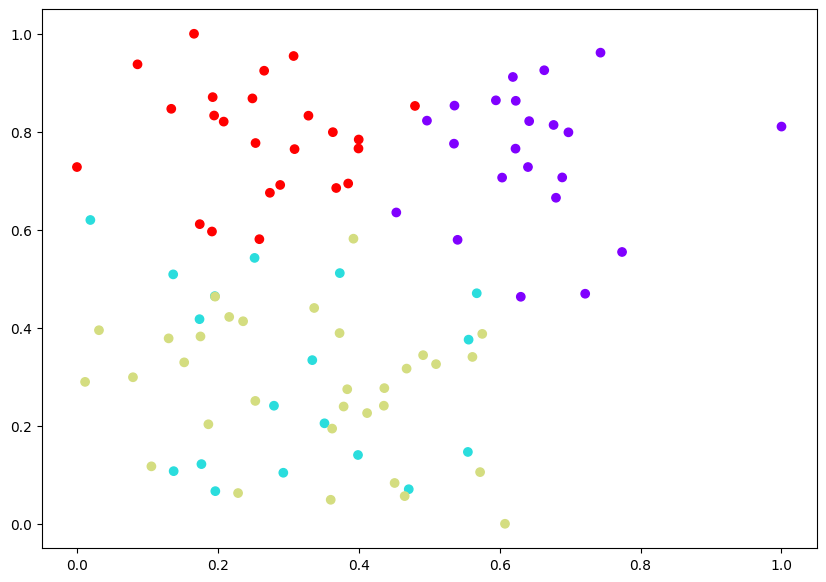

In [67]:
plt.figure(figsize=(10, 7))  
plt.scatter(zscore_df['asisten_porcen_minuto'], zscore_df['tiempo_juego'], c=cluster_kmeans.Cluster, cmap='rainbow') 

## Visualizacion en 3D

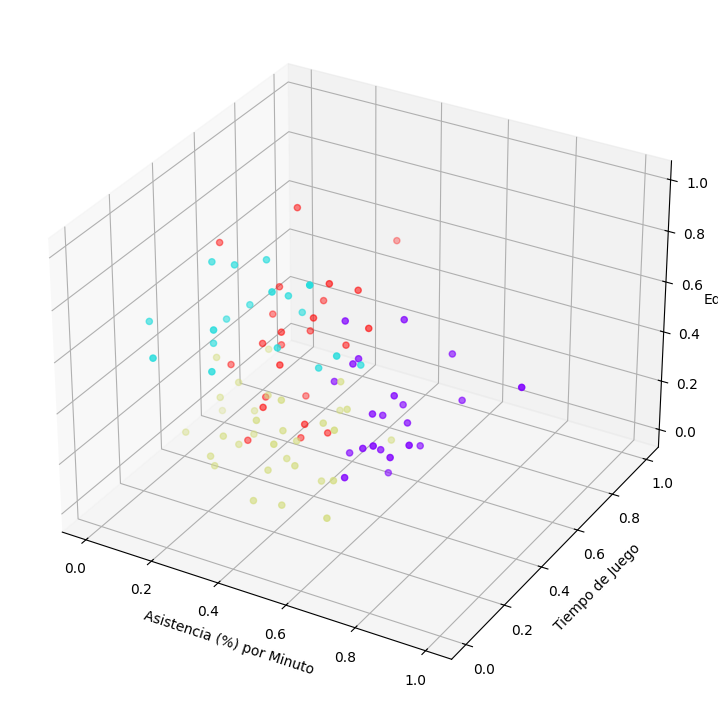

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (18, 9)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(zscore_df.asisten_porcen_minuto, zscore_df.puntos_porcen_minuto, zscore_df.edad, c=cluster_kmeans.Cluster ,cmap='rainbow')

# Etiquetas de los ejes
ax.set_xlabel('Asistencia (%) por Minuto')
ax.set_ylabel('Tiempo de Juego')
ax.set_zlabel('Edad')

# Mostrar el gráfico
plt.show()

### Métrica de Silueta

In [69]:
from sklearn.metrics import silhouette_score
silhouette_score(basket.values, cluster_kmeans.Cluster, metric='euclidean')

0.208610453531354

Como conclusión, el mejor cluster que hemos observado ligeramente mejor que los demás es el medoide